![Astrofisica Computacional](../../new_logo.png)

# Computational Astrophysics –  ML Decision Trees IV (Stellar Type)

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---
Taken from previous lectures of this course.


## Tipos Estelares

Consideraremos un conjunto de datos de [Deepraj Baidya](https://www.kaggle.com/deepu1109), disponible en:

[https://www.kaggle.com/datasets/deepu1109/star-dataset](https://www.kaggle.com/datasets/deepu1109/star-dataset)

Este conjunto de datos incluye 240 objetos (muestras) y 7 características estelares:

- Temperatura absoluta [$K$]
- Luminosidad relativa [$L/L_{\odot}$]
- Radio relativo [$R/R_{\odot}$]
- Magnitud absoluta [$M_v$]
- Color estelar [blanco, rojo, azul, amarillo, amarillo-naranja, etc.]
- Clase espectral [O, B, A, F, G, K, M]
- Tipo estelar [enana roja, enana marrón, enana blanca] [Enana, Secuencia Principal, Supergigante, Hipergigante]**

donde

$L_{\odot} = 3,828 \times 10^{26}$ Watts (Luminosidad media del Sol)

$R_{\odot} = 6,9551 \times 10^8$ m (Radio medio del Sol).

Los datos son una combinación de valores observacionales y sintéticos. Queremos entrenar un algoritmo de árbol de decisión que prediga el *Tipo de Estrella* a partir de las otras 6 características del conjunto de datos.

## El diagrama de Hertzsprung-Russell
La clasificación de las estrellas se suele realizar utilizando la temperatura y la luminosidad. Este tipo de clasificación se representa en el diagrama de Hertzsprung-Russell:
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/6/6b/HRDiagram.png" >
</center>

---

## Los datos

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('6class.csv')
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O
237,8829,537493.000000,1423.0000,-10.73,5,White,A
238,9235,404940.000000,1112.0000,-11.23,5,White,A


Usaremos estos datos para obtener el diagrama de Hertzsprung-Russell,

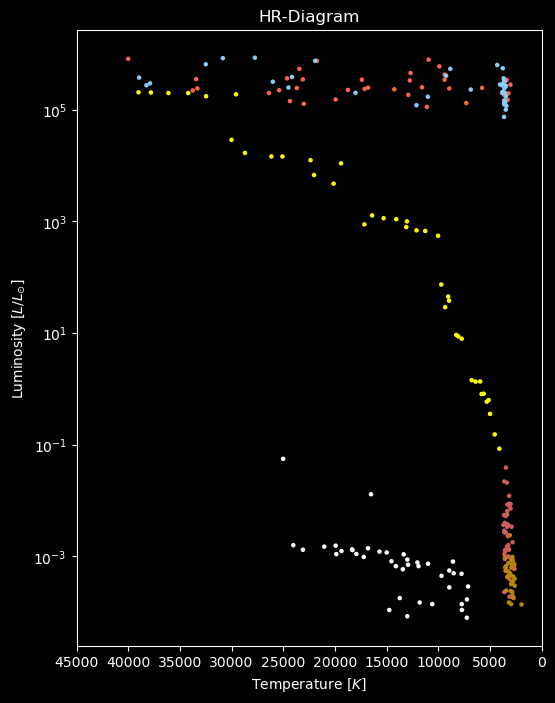

In [3]:
colors = {0:'darkgoldenrod' , 1:'indianred', 2:'white', 3:'yellow', 4:'tomato', 5:'lightskyblue'}

plt.style.use('dark_background')
plt.figure(figsize=(6,8))
plt.scatter(df['Temperature (K)'], df['Luminosity(L/Lo)'], marker='.',
            c = [colors[i] for i in df['Star type']],
            s=20)

plt.xlim(45000,0)
plt.yscale('log')
plt.xlabel(r'Temperature [$K$]')
plt.ylabel(r'Luminosity [$L/L_{\odot}$]')
plt.title('HR-Diagram')
plt.show()

--- 
## Preparación de los datos

Al usar el método `.describe()`, observamos que las características `'Color de la estrella'` y `'Clase espectral'` no son números, sino cadenas de texto.

In [4]:
# Usar el atributo .describe()

Los valores de la característica `'Clase espectral'` y sus recuentos correspondientes son

In [5]:
# Usar el atributo .value_counts() para obtener un conteo de cada Spectral class

Spectral Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

Tenga en cuenta que Python identifica las 7 clases espectrales como valores únicos,

Por otro lado, la información del "Star color" da muchos valores diferentes,

In [7]:
# Usar el atributo .value_counts() para obtener un conteo de cada Star color

Star color
Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Yellowish White         3
Blue white              3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Blue                    1
Yellowish               1
Orange-Red              1
Blue white              1
Blue-White              1
Name: count, dtype: int64

Para simplificar esta información, redefiniremos los colores manualmente:

In [8]:
## Simplification of the color information
# Todas las combinaciones blue white serán "Blue-White"
# Todas las combinaciones que tengan yellow white o yellowish serán "Yellow-White"
# Todas las combinaciones que sean white whitish serán "White"
# Cualquiera que diga orange en su string se convierte en "Red"
# Tener cuidado y remover espacios en blaco al inicio y al final

# usar adecuadamente .replace()

Por lo tanto, al final obtedríamos solo cinco colores de estrella.

In [9]:
df['Star color'].value_counts()

Star color
Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Yellowish White         3
Blue white              3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Blue                    1
Yellowish               1
Orange-Red              1
Blue white              1
Blue-White              1
Name: count, dtype: int64

In [10]:
df['Star color'].unique()

<ArrowStringArray>
[               'Red',         'Blue White',              'White',
    'Yellowish White',         'Blue white', 'Pale yellow orange',
               'Blue',         'Blue-white',            'Whitish',
       'yellow-white',             'Orange',       'White-Yellow',
              'white',              'Blue ',          'yellowish',
          'Yellowish',         'Orange-Red',        'Blue white ',
         'Blue-White']
Length: 19, dtype: str

Una vez que modifiquemos esta característica y para trabajar con esta información, la convertiremos en valores enteros utilizando el método [Series.map()](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html).

In [11]:
# Este truco es más complicado así que lo pongo directamente

star_color_label = {value: key for key, value in enumerate(df['Star color'].unique())}
spec_class_label = {value: key for key, value in enumerate(df['Spectral Class'].unique())}

df['Star color'] = df['Star color'].map(star_color_label)
df['Spectral Class'] = df['Spectral Class'].map(spec_class_label)

df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,0,0
1,3042,0.000500,0.1542,16.60,0,0,0
2,2600,0.000300,0.1020,18.70,0,0,0
3,2800,0.000200,0.1600,16.65,0,0,0
4,1939,0.000138,0.1030,20.06,0,0,0
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,6,4
236,30839,834042.000000,1194.0000,-10.63,5,6,4
237,8829,537493.000000,1423.0000,-10.73,5,2,2
238,9235,404940.000000,1112.0000,-11.23,5,2,2


Los nuevos valores de `'Star color'` son

In [13]:
df['Star color'].value_counts()

(array([0, 1, 2, 3, 4]),
 0    116
 4     56
 1     41
 3     15
 2     12
 Name: Star color, dtype: int64)

y los nuevos valores de  `'Spectral class'` son

In [12]:
df['Spectral Class'].value_counts()

Spectral Class
0    111
1     46
4     40
2     19
3     17
5      6
6      1
Name: count, dtype: int64

La matriz de correlación proporciona la siguiente información.

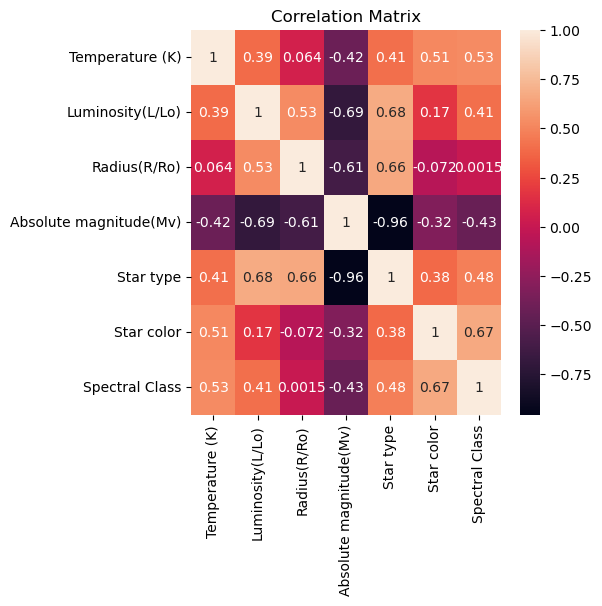

In [13]:
import seaborn as sns
plt.style.use('default')
plt.figure(figsize=(5, 5))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

--- 
## El árbol de decisión

El primer paso será definir las variables objetivo y las características, y luego dividir el conjunto de datos en subconjuntos de entrenamiento y prueba.

In [15]:
# Crear los arrays con los cuatro indices 
# features = (nsize, 6)
# target = array redshifts
# classes = array spec_class



In [16]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_targets, test_targets = train_test_split(features, targets, random_state=1803, test_size=0.4)

In [17]:
train_features.shape, train_targets.shape

((144, 6), (144,))

Antes de entrenar el clasificador, utilizaremos la función [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) para estandarizar las características (eliminando la media y escalándolas a varianza unitaria).

In [18]:
# Paso que dejo explicito
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
train_features = sc.fit_transform(train_features)
test_features = sc.transform(test_features)

Ahora, importamos la clase [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/tree.html) (Tenga en cuenta que `DecisionTreeClassifier` se usa para objetivos con valores enteros, mientras que `DecisionTreeRegressor` se usa cuando los objetivos son números de coma flotante).

Probaremos con una profundidad de árbol de 5.

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

d_tree = DecisionTreeClassifier(max_depth=5)

d_tree

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [20]:
d_tree.fit(train_features, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Predeciremos los resultados utilizando el subconjunto `'test_features'`,

In [21]:
predictions = d_tree.predict(test_features)

La función [sklearn.metrics.classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) muestra un informe con las principales métricas de clasificación. ¡En este caso, los resultados son excelentes!

In [22]:
print(classification_report(test_targets, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00        16

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



La función [sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) calcula la precisión de la predicción. Si el conjunto completo de etiquetas predichas coincide exactamente con el conjunto real de etiquetas, la precisión es 1.0; de lo contrario, es 0.0.

In [23]:
accuracy_score(test_targets, predictions)

1.0

Incluso nuestro criterio anterior de la mediana de los residuos da este tiempo

In [24]:
np.median(np.abs(predictions - test_targets))

np.float64(0.0)

Una matriz de confusión de predicción vs. objetivos muestra los excelentes resultados del algoritmo de clasificación,

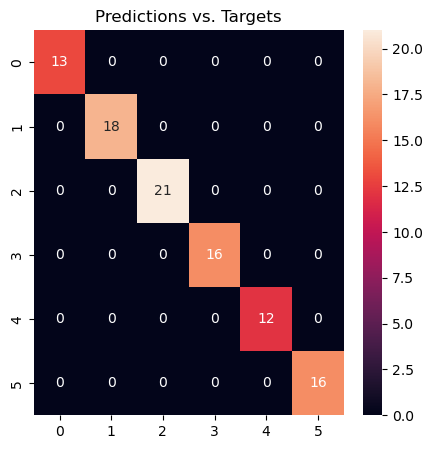

In [25]:
plt.figure(figsize=(5, 5))
sns.heatmap(confusion_matrix(test_targets, predictions), annot=True)
plt.title('Predictions vs. Targets')
plt.show()

Finalmente, es posible visualizar el árbol de decisiones:

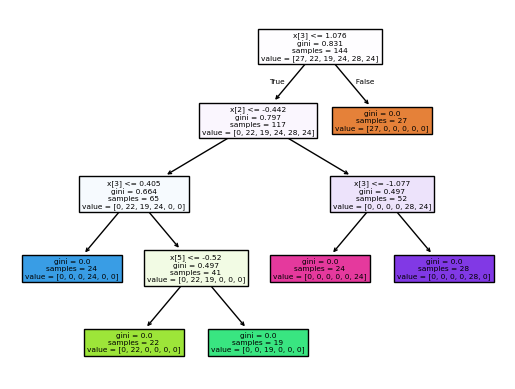

In [26]:
from sklearn import tree

fig = plt.figure()
_ = tree.plot_tree(d_tree, filled=True)